In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
import numpy as np

In [2]:
INPUT_FILE = "../../data/regional_edv_data.csv"
OUTPUT_FILE = "../../data/edv_seasonality.csv"
PLOT_OUTPUT_FILE = "../../plots/edv_seasonality.png"
USE_LN = True

In [3]:
OMEGA = 1/365.25
PHI = 2*np.pi*OMEGA

def f(t, beta_0, beta_s, beta_c):
    if USE_LN:
        return np.exp(beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t))
    else:
        return beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t)

In [4]:
df = pd.read_csv(INPUT_FILE, index_col=0)
y_min = df.values.min()
y_max = df.values.max()
y_range = y_max - y_min
df.head()

,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8,Region 9,Region 10
temporal,,,,,,,,,,
2018-01-01,7,11,7,0,9,0,33,0,0,48
2018-01-02,0,13,10,5,8,0,126,0,0,0
2018-01-03,0,6,4,3,0,5,34,0,11,0
2018-01-04,11,5,0,8,6,0,0,0,16,0
2018-01-05,14,4,4,3,11,0,0,0,5,20


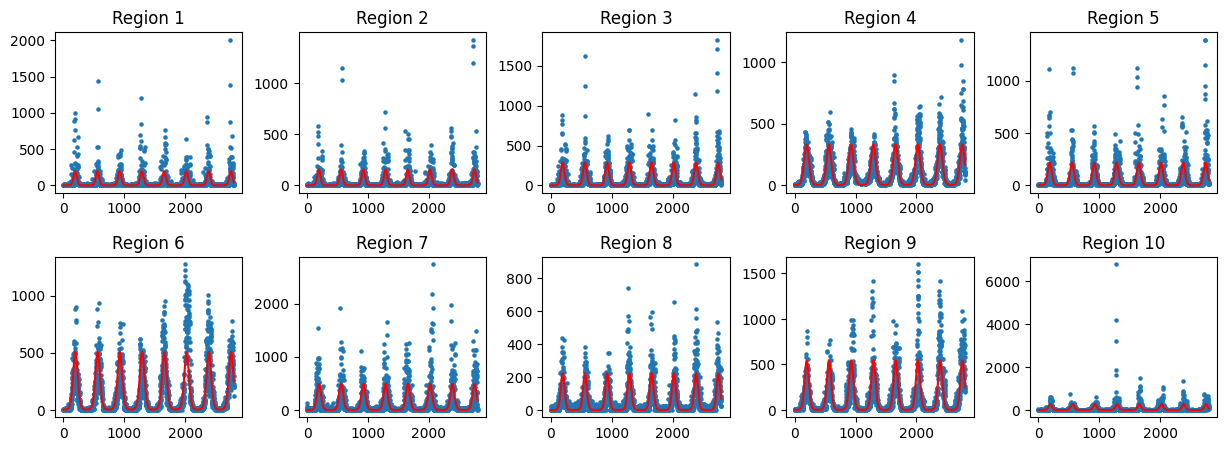

,region,beta_0,beta_s,beta_c,sigma_00,sigma_0s,sigma_0c,sigma_ss,sigma_sc,sigma_cc,psi,var_psi,peak_T,sigma_peak_T,peak_T_CI_lower,peak_T_CI_upper,gamma,var_gamma,theta
0,Region 1,0.708293,-0.811751,-4.501966,0.088844,0.016333,0.092024,0.008852,0.015990,0.096173,0.178394,0.000288,192.995255,0.985749,191.063224,194.927287,4.574564,0.087839,96.985774
1,Region 2,0.187186,-0.765337,-4.802151,0.089110,0.014527,0.092355,0.007857,0.014279,0.096445,0.158045,0.000237,191.812345,0.895562,190.057077,193.567614,4.862756,0.089812,129.380235
2,Region 3,1.726090,-0.662917,-3.883513,0.032441,0.005651,0.033905,0.003567,0.005527,0.035854,0.169071,0.000171,192.453311,0.759293,190.965125,193.941497,3.939687,0.033106,51.402499
3,Region 4,3.516992,-0.536016,-2.229104,0.002656,0.000641,0.002828,0.000604,0.000602,0.003140,0.235982,0.000089,196.342975,0.548866,195.267217,197.418733,2.292644,0.002727,9.901084
4,Region 5,1.908161,-0.284708,-3.468005,0.033051,0.002752,0.035146,0.003392,0.002708,0.037875,0.081912,0.000263,187.386642,0.942182,185.540000,189.233284,3.479672,0.037203,32.449070
5,Region 6,3.730376,-0.636023,-2.415741,0.004166,0.001099,0.004391,0.000900,0.001036,0.004795,0.257440,0.000103,197.590350,0.589612,196.434732,198.745968,2.498065,0.004033,12.158948
6,Region 7,3.092790,-0.572715,-3.052673,0.017394,0.003312,0.018369,0.002521,0.003208,0.019785,0.185455,0.000202,193.405764,0.825460,191.787893,195.023635,3.105932,0.018036,22.330023
7,Region 8,1.769046,-0.711086,-3.567539,0.013173,0.002667,0.013758,0.001691,0.002591,0.014580,0.196743,0.000090,194.061913,0.551337,192.981313,195.142514,3.637716,0.013094,38.004944
8,Region 9,3.381579,-0.800046,-2.806518,0.006962,0.001983,0.007229,0.001363,0.001877,0.007710,0.277701,0.000100,198.768152,0.580901,197.629607,199.906698,2.918325,0.006244,18.510253
9,Region 10,1.113251,-0.975773,-4.398309,0.163605,0.036718,0.168260,0.019041,0.035663,0.174818,0.218316,0.000555,195.315996,1.369620,192.631590,198.000402,4.505247,0.152429,90.490702


In [5]:
fig, axs = plt.subplots(2, 5, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.4)
data = []
for i, region in enumerate(df.columns):
    x = np.arange(len(df.index))
    y = df[region]
    betas, covs = curve_fit(f, x, y)

    beta_0, beta_s, beta_c = betas
    (sigma_00, sigma_0s, sigma_0c),\
    (_,        sigma_ss, sigma_sc),\
    (_,        _,        sigma_cc) = covs

    psi = np.arctan(beta_s/beta_c)
    var_psi = ((beta_c**2 * sigma_ss) + (beta_s**2 * sigma_cc) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)**2
    if beta_s > 0 and beta_c > 0:
        peak_T = psi / PHI
    elif beta_c < 0:
        peak_T = (psi + np.pi) / PHI
    else:
        peak_T = (psi + 2*np.pi) / PHI
    sigma_peak_T = np.sqrt(var_psi) / PHI
    z = norm.ppf(0.975)
    peak_T_CI = (peak_T - z*sigma_peak_T, peak_T + z*sigma_peak_T)
    gamma = np.sqrt(beta_c**2 + beta_s**2)
    var_gamma = ((beta_c**2 * sigma_cc) + (beta_s**2 * sigma_ss) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)
    theta = np.exp(gamma)
    M = z # M not specified in paper
    theta_CI = (np.exp(gamma - M*np.sqrt(var_gamma)), np.exp(gamma + M*np.sqrt(var_gamma)))

    data.append({
        "region": region,
        "beta_0": beta_0, "beta_s": beta_s, "beta_c": beta_c,
        "sigma_00": sigma_00, "sigma_0s": sigma_0s, "sigma_0c": sigma_0c, "sigma_ss": sigma_ss, "sigma_sc": sigma_sc, "sigma_cc": sigma_cc,
        "psi": psi, "var_psi": var_psi,
        "peak_T": peak_T, "sigma_peak_T": sigma_peak_T, "peak_T_CI_lower": peak_T_CI[0], "peak_T_CI_upper": peak_T_CI[1],
        "gamma": gamma, "var_gamma": var_gamma, "theta": theta,
        # "theta_CI_lower": theta_CI[0], "theta_CI_upper": theta_CI[1]
    })

    ax = axs[i//5,i%5]
    ax.scatter(x, y, s = 5)
    ax.plot(x, f(x, *betas), color = "red")
    ax.set_title(region)
    # ax.set_ylim(y_min - y_range*0.1, y_max + y_range*0.1)

plt.savefig(PLOT_OUTPUT_FILE, dpi = 500, bbox_inches = "tight")
plt.show()
df_models = pd.DataFrame(data)
df_models

In [6]:
df_models.to_csv(OUTPUT_FILE, index = False)